<a href="https://colab.research.google.com/github/anu04596/Neural-Network-and-Deep-Learning/blob/main/Project3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import zipfile
import os

with zipfile.ZipFile('/content/dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

In [6]:
import os
import pandas as pd

image_dir = '/content/dataset/train_transformed'

files = os.listdir(image_dir)

df = pd.DataFrame({
    'filename': files
})

# Create labels from filename
df['label'] = df['filename'].apply(lambda x: 'cat' if 'cat' in x.lower() else 'dog')

df.head()

,filename,label
0,dog974.jpg,dog
1,cat649.jpg,cat
2,dog865.jpg,dog
3,dog122.jpg,dog
4,cat809.jpg,cat


In [7]:
df['filepath'] = df['filename'].apply(lambda x: os.path.join(image_dir, x))
df.head()

,filename,label,filepath
0,dog974.jpg,dog,/content/dataset/train_transformed/dog974.jpg
1,cat649.jpg,cat,/content/dataset/train_transformed/cat649.jpg
2,dog865.jpg,dog,/content/dataset/train_transformed/dog865.jpg
3,dog122.jpg,dog,/content/dataset/train_transformed/dog122.jpg
4,cat809.jpg,cat,/content/dataset/train_transformed/cat809.jpg


Import Libraries

In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Image Preprocessing

In [9]:
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

Load Data using DataFrame

In [10]:
train_data = datagen.flow_from_dataframe(
    dataframe=df,
    x_col='filepath',
    y_col='label',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_dataframe(
    dataframe=df,
    x_col='filepath',
    y_col='label',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 1600 validated image filenames belonging to 2 classes.
Found 400 validated image filenames belonging to 2 classes.


Build CNN Model

In [11]:
from tensorflow.keras import layers, models

model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [12]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Train Model

In [13]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.4969 - loss: 0.7149 - val_accuracy: 0.6000 - val_loss: 0.6892
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.5487 - loss: 0.6877 - val_accuracy: 0.6300 - val_loss: 0.6586
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.5612 - loss: 0.6832 - val_accuracy: 0.5900 - val_loss: 0.6574
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.5675 - loss: 0.6775 - val_accuracy: 0.5875 - val_loss: 0.6842
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.6019 - loss: 0.6627 - val_accuracy: 0.6250 - val_loss: 0.6535
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.6050 - loss: 0.6519 - val_accuracy: 0.6275 - val_loss: 0.6240
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.6450 - loss: 0.6296 - val_accuracy: 0.6225 - val_loss: 0.6559
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.6481 - loss: 0.6250 - val_accuracy: 0.5725 - val_loss:

Evalaute Model

In [16]:
loss, accuracy = model.evaluate(val_data)
print("Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 371ms/step - accuracy: 0.6675 - loss: 0.6289
Accuracy: 0.6675000190734863


Plot Graphs

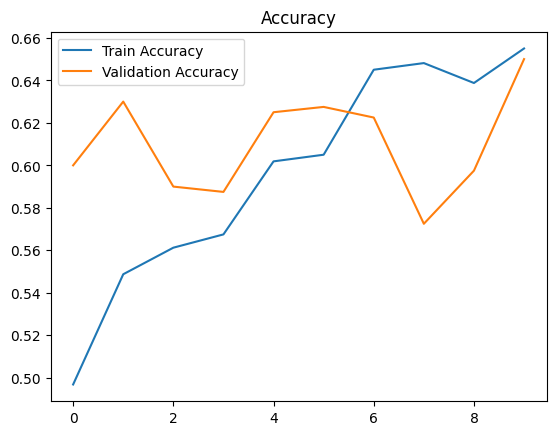

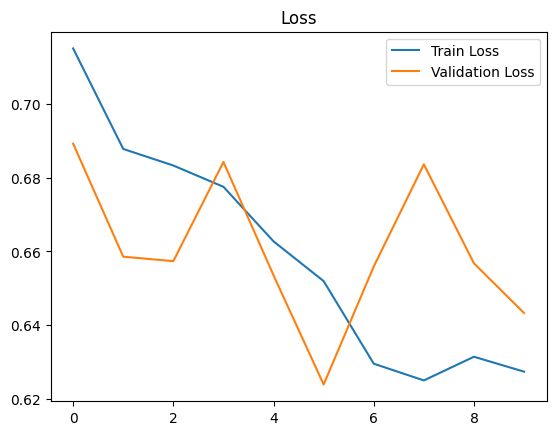

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")
plt.show()